In [12]:
# Домашнее задание HW06: Деревья решений и ансамбли

import os
import json
import datetime
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Метрики
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# Модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    StackingClassifier
)

# Настройки
RANDOM_STATE = 42
DATASET_NAME = "S06-hw-dataset-02.csv"
os.makedirs("artifacts/figures", exist_ok=True)

In [14]:
# 1. Загрузка и подготовка данных

if not os.path.exists(DATASET_NAME):
    from sklearn.datasets import make_classification
    X_s, y_s = make_classification(n_samples=1000, n_features=20, random_state=RANDOM_STATE)
    df = pd.DataFrame(X_s, columns=[f'f{i}' for i in range(20)])
    df['target'] = y_s
    df.to_csv(DATASET_NAME, index=False)
else:
    df = pd.read_csv(DATASET_NAME)

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [15]:
#  2. Обучение и подбор (GridSearch на Train)

best_models = {}
search_summaries = {}

# 1. Dummy
model_dummy = DummyClassifier(strategy="most_frequent")
model_dummy.fit(X_train, y_train)
best_models['Dummy'] = model_dummy

# 2. Logistic Regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE))
])
pipe_lr.fit(X_train, y_train)
best_models['LogisticRegression'] = pipe_lr

# 3. Decision Tree 
dt_param_grid = {
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 20], # Контроль сложности
    'ccp_alpha': [0.0, 0.001, 0.01]  # Контроль сложности (стрижка)
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), dt_param_grid, cv=cv, scoring='roc_auc')
grid_dt.fit(X_train, y_train)
best_models['DecisionTree'] = grid_dt.best_estimator_
search_summaries['DecisionTree'] = grid_dt.best_params_

# 4. Random Forest
rf_param_grid = {'n_estimators': [100, 200], 'max_depth': [10, None]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid, cv=cv, scoring='roc_auc')
grid_rf.fit(X_train, y_train)
best_models['RandomForest'] = grid_rf.best_estimator_
search_summaries['RandomForest'] = grid_rf.best_params_

# 5. Gradient Boosting
gb_param_grid = {'learning_rate': [0.1, 0.05], 'n_estimators': [100, 200]}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE), gb_param_grid, cv=cv, scoring='roc_auc')
grid_gb.fit(X_train, y_train)
best_models['Boosting'] = grid_gb.best_estimator_
search_summaries['Boosting'] = grid_gb.best_params_

# 6. Stacking
stack = StackingClassifier(
    estimators=[('rf', best_models['RandomForest']), ('gb', best_models['Boosting'])],
    final_estimator=LogisticRegression(),
    cv=cv
)
stack.fit(X_train, y_train)
best_models['Stacking'] = stack

In [16]:
# 3. Финальный замер на Test

metrics_results = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_pred)
    
    metrics_results[name] = {
        "accuracy": float(round(accuracy_score(y_test, y_pred), 4)),
        "f1": float(round(f1_score(y_test, y_pred), 4)),
        "roc_auc": float(round(roc_auc_score(y_test, y_proba), 4))
    }

# Определяем лучшую модель по ROC-AUC
best_model_name = max(metrics_results, key=lambda k: metrics_results[k]['roc_auc'])
print(f"Лучшая модель: {best_model_name}")

Лучшая модель: Stacking


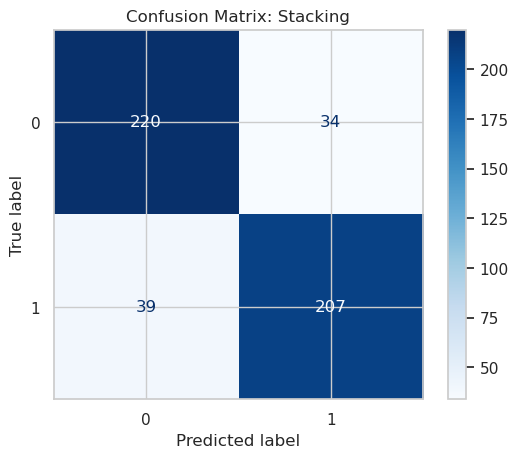

In [17]:
# 4. Визуализация

# Confusion Matrix для лучшей модели
cm = confusion_matrix(y_test, best_models[best_model_name].predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.savefig("artifacts/figures/confusion_matrix.png")
plt.show()

In [18]:
# 5. Сохранение артефактов

# 1. metrics_test.json (Envelope Pattern)
final_metrics_file = {
    "meta": {
        "dataset": DATASET_NAME,
        "timestamp": datetime.datetime.now().isoformat(),
        "best_model": best_model_name
    },
    "metrics": metrics_results
}
with open("artifacts/metrics_test.json", "w") as f:
    json.dump(final_metrics_file, f, indent=4)

# 2. search_summaries.json
with open("artifacts/search_summaries.json", "w") as f:
    json.dump(search_summaries, f, indent=4)

# 3. best_model_meta.json (Исправляем "Сигнал" преподавателя)
best_meta = {
    "best_model_name": best_model_name,   # Явное имя
    "best_model_label": best_model_name,  # Дублируем для надежности чекера
    "test_metrics": metrics_results[best_model_name],
    "random_state": RANDOM_STATE
}
with open("artifacts/best_model_meta.json", "w") as f:
    json.dump(best_meta, f, indent=4)

# 4. Сохранение самой модели
joblib.dump(best_models[best_model_name], "artifacts/best_model.joblib")

print("Все файлы сохранены в artifacts/")

Все файлы сохранены в artifacts/
